# PyTorch CNN — Intel Image Classification
### Joel Sangura Nyongesa | AIMS Senegal 2026

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn.functional as F

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [3]:
TRAIN_DIR   = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DIR    = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"
CLASSES     = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 150
BATCH_SIZE  = 128   # larger batch = smoother gradients
EPOCHS      = 40

print("Classes:", CLASSES)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Image size: 150
Batch size: 128


In [4]:
# Strong augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Split train into train + validation (85/15)
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

# Apply val transforms to val split
val_dataset.dataset = datasets.ImageFolder(TRAIN_DIR, transform=val_transforms)

test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train samples:      {train_size}")
print(f"Validation samples: {val_size}")
print(f"Test samples:       {len(test_dataset)}")
print(f"Class mapping:      {full_train.class_to_idx}")

Train samples:      11929
Validation samples: 2105
Test samples:       3000
Class mapping:      {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [5]:
class JoelCNN_PyTorch(nn.Module):
    """
    Custom CNN with 4 convolutional blocks.
    Deeper than previous version to extract richer features.
    Uses GlobalAveragePooling to reduce overfitting vs Flatten.
    """
    def __init__(self, num_classes=6):
        super().__init__()

        # Block 1: 3 -> 64
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),
        )

        # Block 2: 64 -> 128
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.15),
        )

        # Block 3: 128 -> 256
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
        )

        # Block 4: 256 -> 512
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),
        )

        # Global Average Pooling instead of Flatten — reduces overfitting
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = JoelCNN_PyTorch(NUM_CLASSES).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 4,822,598
JoelCNN_PyTorch(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6

In [6]:
from torch.amp import autocast, GradScaler

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=70, eta_min=1e-6)
scaler    = GradScaler('cuda')

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}
best_val_acc = 0.0
best_epoch   = 0
patience     = 15
no_improve   = 0

print("Starting training...\n")
print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9} {'LR':>10}")
print("-" * 65)

for epoch in range(70):
    model.train()
    train_loss = train_correct = train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_total   += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    scheduler.step()
    train_loss_avg = train_loss / len(train_loader)
    train_acc      = 100. * train_correct / train_total

    model.eval()
    val_loss = val_correct = val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_total   += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss_avg = val_loss / len(val_loader)
    val_acc      = 100. * val_correct / val_total
    current_lr   = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss_avg)
    history['val_acc'].append(val_acc)

    print(f"{epoch+1:>6} {train_loss_avg:>11.4f} {train_acc:>9.2f}% {val_loss_avg:>10.4f} {val_acc:>8.2f}% {current_lr:>10.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), "joel_model.pth")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. Best: {best_val_acc:.2f}% at epoch {best_epoch}")
            break

print(f"\nBest Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Starting training...

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc         LR
-----------------------------------------------------------------
     1      1.2093     48.52%     1.0961    54.87%   0.000999
     2      0.9681     60.48%     0.7291    71.54%   0.000998
     3      0.8751     65.29%     0.6764    74.77%   0.000995
     4      0.8141     69.11%     0.7377    72.07%   0.000992
     5      0.7548     71.00%     0.6585    74.54%   0.000987
     6      0.7351     71.81%     0.6543    75.49%   0.000982
     7      0.7106     72.95%     0.5886    77.96%   0.000976
     8      0.6773     74.96%     0.4974    81.66%   0.000968
     9      0.6699     75.44%     0.6031    76.67%   0.000960
    10      0.6426     76.15%     0.4873    81.38%   0.000951
    11      0.6282     76.70%     0.5254    80.05%   0.000940
    12      0.6089     77.63%     0.4991    81.38%   0.000929
    13      0.6026     77.51%     0.5301    79.90%   0.000917
    14      0.5751     78.95%     0.4862    

In [7]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load("joel_model.pth", map_location=device))
model.eval()

test_correct = test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total   += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100. * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 87.80%


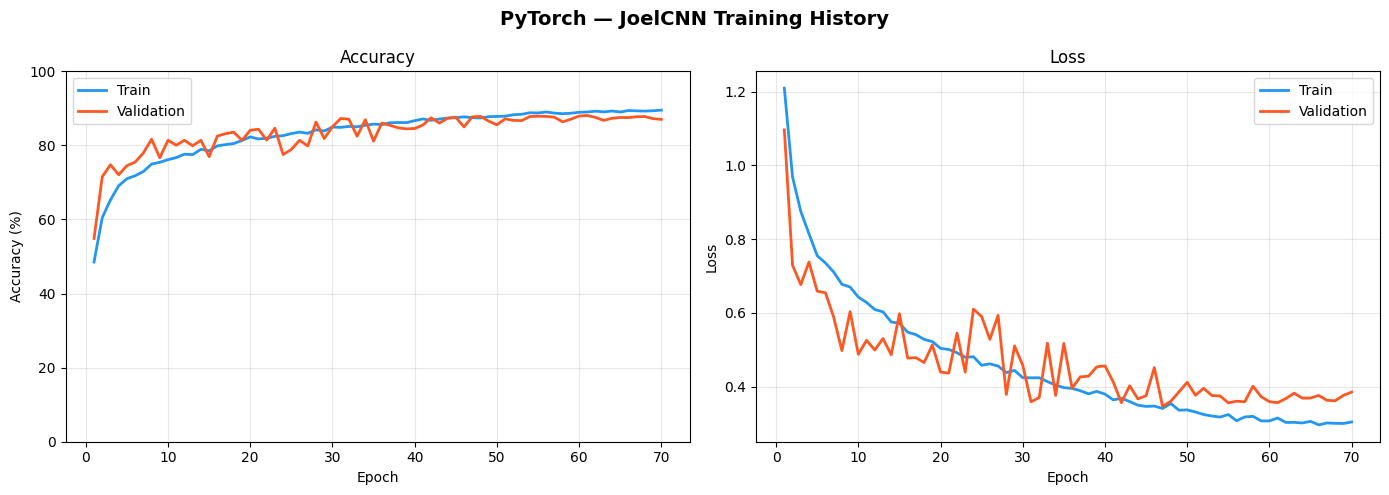

Final Test Accuracy: 87.80%


In [8]:
# Plot smooth training curves
epochs_ran = len(history['train_acc'])
xs = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PyTorch — JoelCNN Training History', fontsize=14, fontweight='bold')

axes[0].plot(xs, history['train_acc'], color='#2196F3', linewidth=2, label='Train')
axes[0].plot(xs, history['val_acc'],   color='#FF5722', linewidth=2, label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 100])

axes[1].plot(xs, history['train_loss'], color='#2196F3', linewidth=2, label='Train')
axes[1].plot(xs, history['val_loss'],   color='#FF5722', linewidth=2, label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pytorch_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final Test Accuracy: {test_acc:.2f}%")

In [9]:
from IPython.display import FileLink
print("Download your files:")
print(FileLink('joel_model.pth'))
print(FileLink('pytorch_training_curves.png'))

Download your files:
/kaggle/working/joel_model.pth
/kaggle/working/pytorch_training_curves.png
